In [2]:
from network import *
%run network

Number of subnetworks: 69


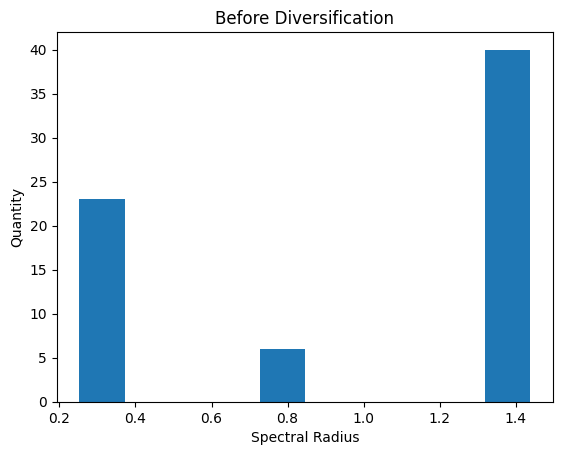

Percentage of subnetworks with spectral radius >= 1: 0.5797101449275363


In [201]:
%run network
n1 = SupplyChainNetwork.generate(num_nodes=25, num_edges=40, num_colors=4)
print("Number of subnetworks:", len(n1.subnetworks))
subnetwork_radii = [np.abs(eigs(nx.adjacency_matrix(G), k=1, which="LM")[0][0]) for G in n1.subnetworks]

plt.hist(subnetwork_radii)

plt.xlabel("Spectral Radius")
plt.ylabel("Quantity")
plt.title("Before Diversification")
plt.show()

print("Percentage of subnetworks with spectral radius >= 1:", sum(1 for radius in subnetwork_radii if radius >= 1) / len(subnetwork_radii))

Number of subnetworks: 116


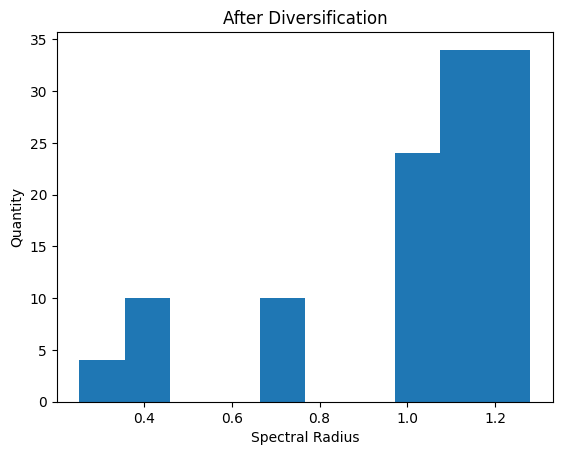

Percentage of subnetworks with spectral radius >= 1: 0.5862068965517241


In [202]:
n1.diversify(1/3)
n1._subnetworks = n1.calculate_subnetworks()
print("Number of subnetworks:", len(n1.subnetworks))
subnetwork_radii = [np.abs(eigs(nx.adjacency_matrix(G), k=1, which="LM")[0][0]) for G in n1.subnetworks]

plt.hist(subnetwork_radii)

plt.xlabel("Spectral Radius")
plt.ylabel("Quantity")
plt.title("After Diversification")
plt.show()

print("Percentage of subnetworks with spectral radius >= 1:", sum(1 for radius in subnetwork_radii if radius >= 1) / len(subnetwork_radii))

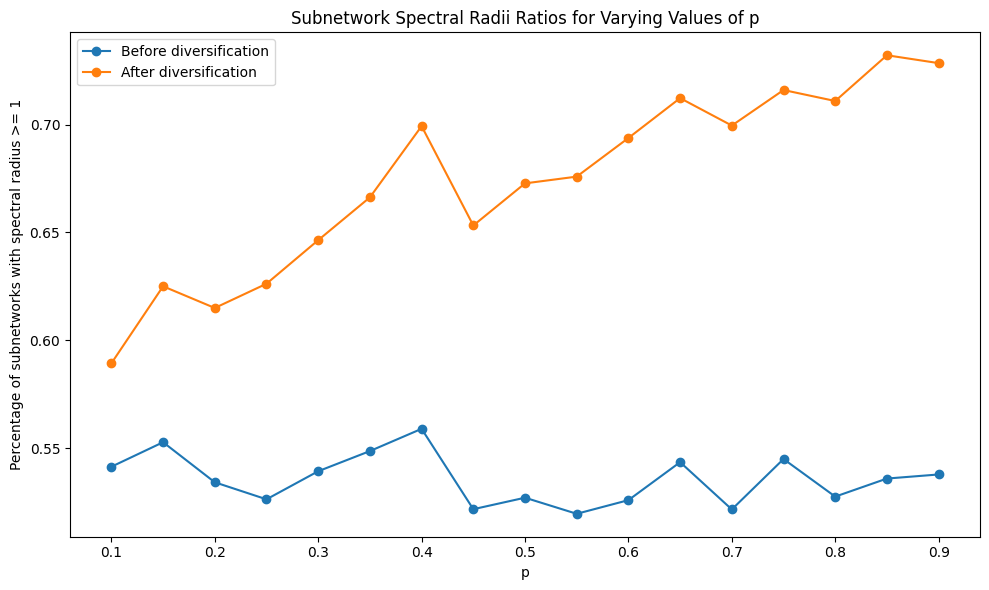

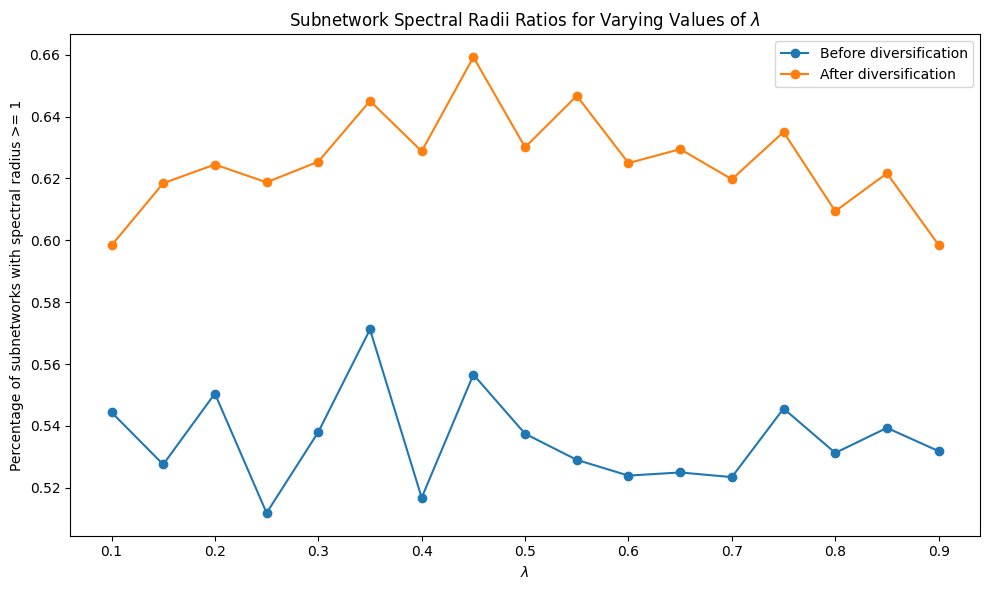

In [ ]:
p_vals = np.linspace(0.1, 0.9, 17)
subnetwork_ratios_original = []
subnetwork_ratios_diversified = []

for p in p_vals:
    original_ratios = []
    diversified_ratios = []
    for _ in range(1000):
        n1 = SupplyChainNetwork.generate(num_nodes=25, num_edges=40, num_colors=4)
        subnetwork_radii = [max(abs(np.linalg.eigvals(nx.adjacency_matrix(G).toarray()))) for G in n1.subnetworks]
        ratio = sum(1 for radius in subnetwork_radii if radius >= 1) / len(subnetwork_radii)
        original_ratios.append(ratio)

        n1.diversify(p)
        subnetwork_radii = [max(abs(np.linalg.eigvals(nx.adjacency_matrix(G).toarray()))) for G in n1.subnetworks]
        ratio = sum(1 for radius in subnetwork_radii if radius >= 1) / len(subnetwork_radii)
        diversified_ratios.append(ratio)
    subnetwork_ratios_original.append(np.mean(original_ratios))
    subnetwork_ratios_diversified.append(np.mean(diversified_ratios))

plt.figure(figsize=(10, 6))
plt.plot(p_vals, subnetwork_ratios_original, 'o-', label="Before diversification")
plt.plot(p_vals, subnetwork_ratios_diversified, 'o-', label="After diversification")
plt.xlabel("p")
plt.ylabel("Percentage of subnetworks with spectral radius >= 1")
plt.title("Subnetwork Spectral Radii Ratios for Varying Values of p")
plt.legend()

plt.tight_layout()
plt.show()

lam_vals = np.linspace(0.1, 0.9, 17)
subnetwork_ratios_original = []
subnetwork_ratios_diversified = []

for lam in lam_vals:
    original_ratios = []
    diversified_ratios = []
    for _ in range(1000):
        n1 = SupplyChainNetwork.generate(num_nodes=25, num_edges=40, num_colors=4)
        subnetwork_radii = [max(abs(np.linalg.eigvals(nx.adjacency_matrix(G).toarray()))) for G in n1.subnetworks]
        ratio = sum(1 for radius in subnetwork_radii if radius >= 1) / len(subnetwork_radii)
        original_ratios.append(ratio)

        n1.diversify(p=0.25, lam=lam)
        subnetwork_radii = [max(abs(np.linalg.eigvals(nx.adjacency_matrix(G).toarray()))) for G in n1.subnetworks]
        ratio = sum(1 for radius in subnetwork_radii if radius >= 1) / len(subnetwork_radii)
        diversified_ratios.append(ratio)
    subnetwork_ratios_original.append(np.mean(original_ratios))
    subnetwork_ratios_diversified.append(np.mean(diversified_ratios))

plt.figure(figsize=(10, 6))
plt.plot(lam_vals, subnetwork_ratios_original, 'o-', label="Before diversification")
plt.plot(lam_vals, subnetwork_ratios_diversified, 'o-', label="After diversification")
plt.xlabel(r"$\lambda$")
plt.ylabel("Percentage of subnetworks with spectral radius >= 1")
plt.title(r"Subnetwork Spectral Radii Ratios for Varying Values of $\lambda$")
plt.legend()

plt.tight_layout()
plt.show()

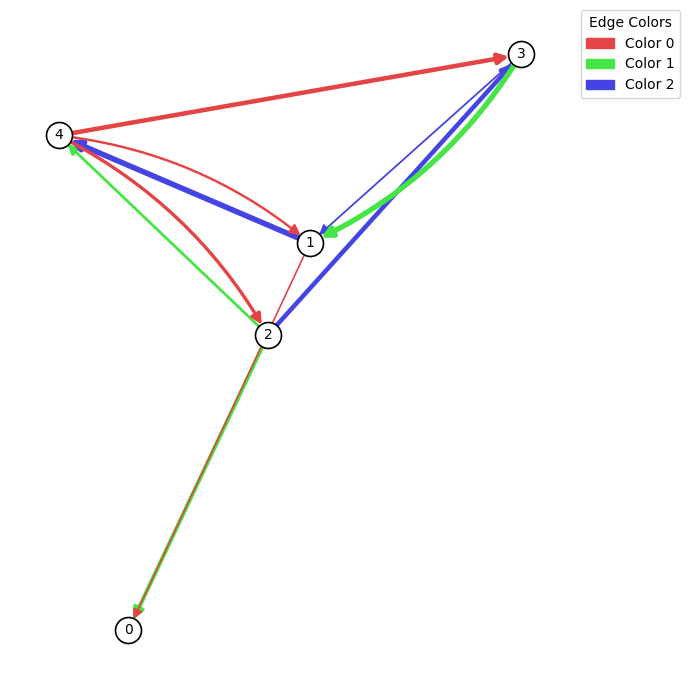

array([[0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.23564463, 0.        , 0.        , 0.        , 1.82338343],
       [1.17360217, 0.        , 0.        , 1.39356952, 0.68197595],
       [0.        , 1.99410455, 0.        , 0.        , 0.        ],
       [0.        , 0.54871001, 0.93259807, 1.39361904, 0.        ]])

In [57]:
%run network
n1 = SupplyChainNetwork.generate(num_nodes=5, num_edges=10, num_colors=3)
n1.visualize_supply_chain()

nx.adjacency_matrix(n1.G, nodelist=range(n1.num_nodes)).toarray()

In [58]:
def color_adj_decomp(sc: SupplyChainNetwork):
    n = sc.num_nodes
    color_decomp = {i: np.zeros((n, n)) for i in range(sc.num_colors)}

    for u, v, data in sc.G.edges(data=True):
        c = data["color"]
        w = data["weight"]
        color_decomp[c][u, v] = w

    return color_decomp

In [59]:
decomp = color_adj_decomp(n1)
decomp

{0: array([[0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.23564463, 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.54871001, 0.93259807, 1.39361904, 0.        ]]),
 1: array([[0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [1.17360217, 0.        , 0.        , 0.        , 0.68197595],
        [0.        , 1.70205893, 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ]]),
 2: array([[0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 1.82338343],
        [0.        , 0.        , 0.        , 1.39356952, 0.        ],
        [0.        , 0.29204563, 0.        , 0.        , 0.        ],
       

In [435]:
for _ in range(100):
    n1.diversify(1, 0.5)

color_adj_decomp(n1)

{0: array([[0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.29443301, 0.9417132 , 0.309016  , 1.32976491, 0.        ]]),
 1: array([[0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.58284211, 0.45706911, 0.        , 0.        , 0.8156669 ],
        [0.47192864, 0.34463195, 0.        , 0.        , 0.88549834],
        [0.        , 0.        , 0.        , 0.        , 0.        ]]),
 2: array([[0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.29220528, 0.        , 0.50241133, 0.59895291],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
       

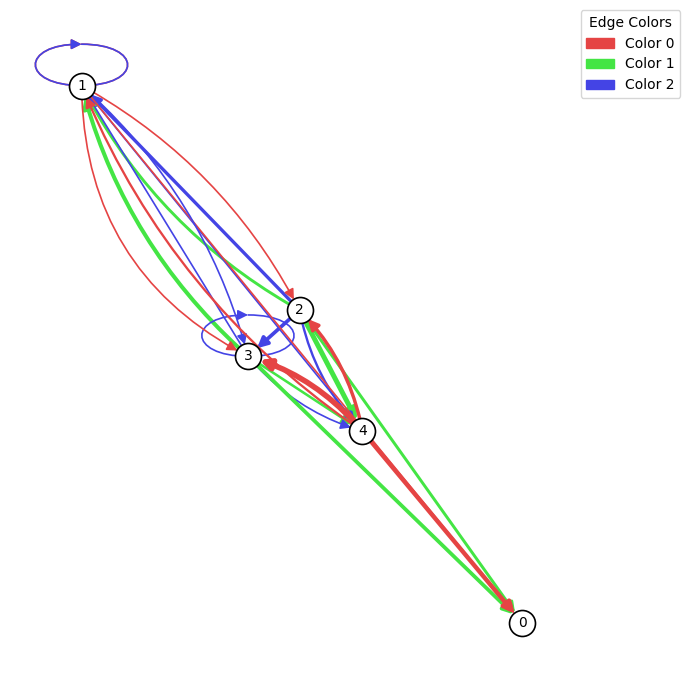

In [397]:
n1.visualize_supply_chain()

In [11]:
np.empty((19,))

array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55,
       0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95])

In [2]:
p_vals = np.linspace(0.1, 0.9, 9)
lambda_vals = np.linspace(0.1, 0.9, 9)
improvement_matrix = np.empty((9, 9))

for i, p in enumerate(p_vals):
    for j, lam in enumerate(lambda_vals):
        original_ratios = []
        diversified_ratios = []
        for _ in range(1000):
            sc = SupplyChainNetwork.generate(num_nodes=25, num_edges=40, num_colors=4)
            subnetwork_radii = [max(abs(np.linalg.eigvals(nx.adjacency_matrix(G).toarray()))) for G in sc.subnetworks]
            ratio = sum(1 for radius in subnetwork_radii if radius >= 1) / len(subnetwork_radii)
            original_ratios.append(ratio)

            sc.diversify(p, lam)
            subnetwork_radii = [max(abs(np.linalg.eigvals(nx.adjacency_matrix(G).toarray()))) for G in sc.subnetworks]
            ratio = sum(1 for radius in subnetwork_radii if radius >= 1) / len(subnetwork_radii)
            diversified_ratios.append(ratio)

        improvement_ratio = np.mean(diversified_ratios) - np.mean(original_ratios)
        improvement_matrix[i, j] = improvement_ratio

np.save('improvement_matrix.npy', improvement_matrix)
print(improvement_matrix)

[[0.03657601 0.04096219 0.05019496 0.04921097 0.06002    0.0488175
  0.05088342 0.04130186 0.03984045]
 [0.04800036 0.0751695  0.07181514 0.0855664  0.07876675 0.08482152
  0.08599206 0.07736069 0.05694305]
 [0.07637808 0.08801677 0.10316088 0.10683961 0.09653091 0.11328439
  0.11305322 0.09608549 0.08345284]
 [0.08239681 0.11780547 0.13719828 0.1255337  0.12434083 0.12065255
  0.12361575 0.11633148 0.08851385]
 [0.08114727 0.12335794 0.10483506 0.14747432 0.14714547 0.13223673
  0.13271893 0.13052045 0.09300413]
 [0.12795701 0.15895621 0.15696829 0.17564377 0.16617852 0.15541307
  0.12904818 0.12541377 0.09711903]
 [0.12998632 0.1662313  0.15201175 0.16700688 0.18324216 0.1721064
  0.14856914 0.15032421 0.08917338]
 [0.16109485 0.1591648  0.16303    0.20754668 0.17268144 0.16493956
  0.1726374  0.13515642 0.09404601]
 [0.147037   0.20660892 0.18991163 0.21281714 0.18773083 0.19422057
  0.16606209 0.13971609 0.10786249]]


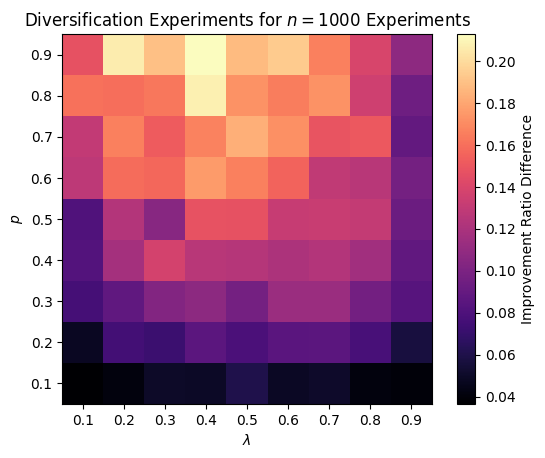

In [ ]:
improvement_matrix = np.load("improvement_matrix.npy")
plt.imshow(improvement_matrix, cmap="magma", origin="upper")
plt.colorbar(label="Improvement Ratio Difference")
plt.title(r"Diversification Experiments for $n=1000$ Experiments")

ax = plt.gca()
ax.set_xlim(-0.5, 8.5)
ax.set_ylim(-0.5, 8.5)

ticks = np.arange(9)
labels = np.round(np.linspace(0.1, 0.9, 9), 1)

ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

plt.xlabel(r"$\lambda$")

plt.ylabel("$p$")
plt.show()